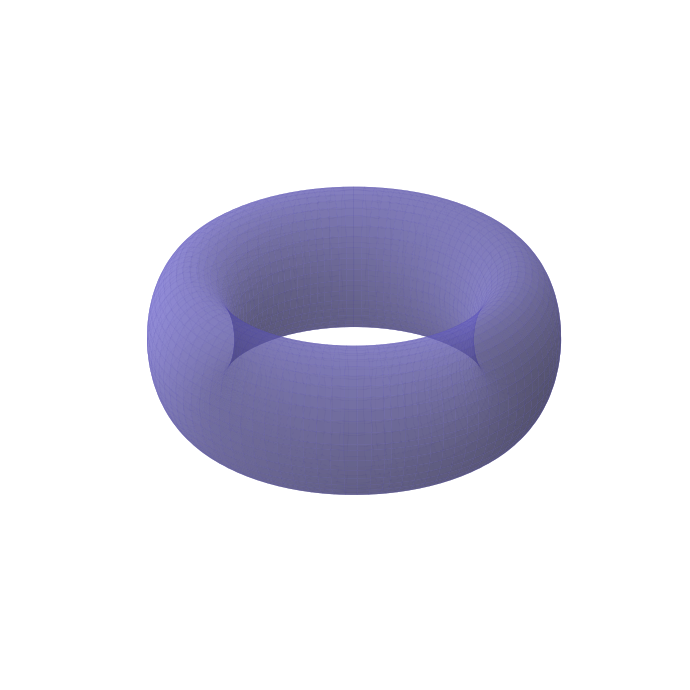

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Elliptical torus parameters ---
R1 = 3.5   # major radius along x
R2 = 2.2   # major radius along y (smaller → elliptical)
r  = 0.8   # tube radius

# --- Parametric surface ---
u = np.linspace(0, 2 * np.pi, 200)
v = np.linspace(0, 2 * np.pi, 80)
U, V = np.meshgrid(u, v)

X = (R1 + r * np.cos(V)) * np.cos(U)
Y = (R2 + r * np.cos(V)) * np.sin(U)
Z = r * np.sin(V)

# --- Plot ---
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.55, color='#7F77DD', edgecolor='#534AB7',
                linewidth=0.08, rstride=2, cstride=2)

ax.set_axis_off()
ax.set_box_aspect([1, 1, 0.35])
ax.view_init(elev=30, azim=-10)

plt.tight_layout()
plt.savefig('torus_R1_R2_r.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

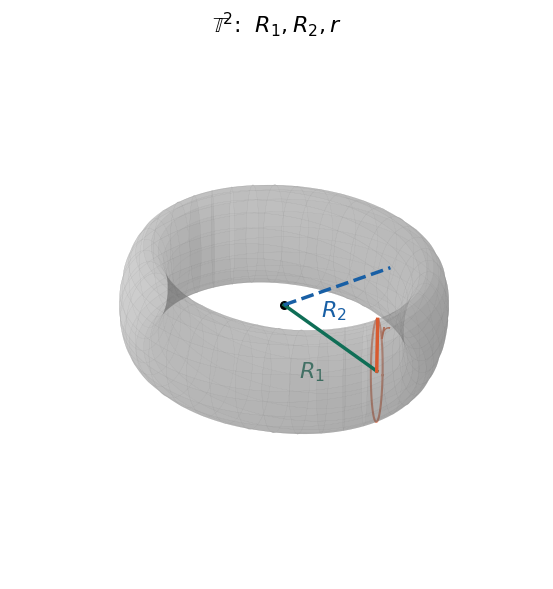

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Torus parameters ---
R1 = 10
R2 = 2.5
r  = 0.6

# --- Parametric surface ---
u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(0, 2 * np.pi, 60)
U, V = np.meshgrid(u, v)

X = (R1 + r * np.cos(V)) * np.cos(U)
Y = (R2 + r * np.cos(V)) * np.sin(U)
Z = r * np.sin(V)

# --- Plot ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.3, color='#B0B0B0', edgecolor='#808080',
                linewidth=0.1, rstride=3, cstride=3)

# --- Annotate R1 ---
ax.plot([0, R1], [0, 0], [0, 0],
        color='#0F6E56', lw=2.5, zorder=10)
ax.text(R1 / 2, -0.4, -0.4, r'$R_1$', fontsize=16, color='#0F6E56',
        fontweight='bold', ha='center')

# --- Annotate R2 ---
ax.plot([0, 0], [0, R2], [0, 0],
        color='#185FA5', lw=2.5, linestyle='--', zorder=10)
ax.text(-0.4, R2 / 2, -0.4, r'$R_2$', fontsize=16, color='#185FA5',
        fontweight='bold', ha='center')

# --- Annotate r ---
ax.plot([R1, R1], [0, 0], [0, r],
        color='#D85A30', lw=2.5, zorder=10)
ax.text(R1 + 0.15, 0, r / 2 + 0.1, r'$r$', fontsize=16, color='#D85A30',
        fontweight='bold', ha='left')

# --- Cross-section ring at u=0 ---
v_ring = np.linspace(0, 2 * np.pi, 100)
cx = R1 + r * np.cos(v_ring)
cy = np.zeros_like(v_ring)
cz = r * np.sin(v_ring)
ax.plot(cx, cy, cz, color='#D85A30', lw=1.5, alpha=0.7)

# --- Center dot ---
ax.scatter([0], [0], [0], color='black', s=30, zorder=10)

# --- Remove axes and grid ---
ax.set_axis_off()
ax.set_title(r'$\mathbb{T}^2$:  $R_1, R_2, r$', fontsize=16, pad=10)

ax.view_init(elev=30, azim=-35)
ax.set_box_aspect([1, 1, 0.35])

plt.tight_layout()
plt.savefig('torus_R1_R2_r.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

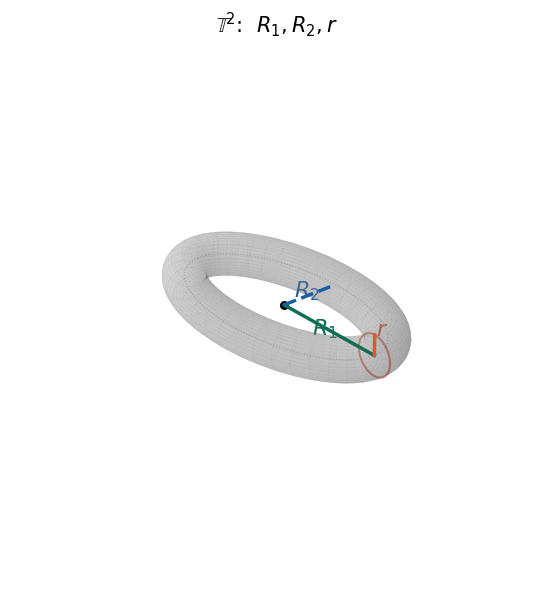

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Torus parameters (tweak these) ---
R1 = 12
R2 = 6
r  = 2
n_surf = 80

# --- Coordinate frame (flat torus in xy-plane) ---
center = np.array([0.0, 0.0, 0.0])
u_ax   = np.array([1.0, 0.0, 0.0])
v_ax   = np.array([0.0, 1.0, 0.0])
axis   = np.array([0.0, 0.0, 1.0])

# --- Elliptical torus mesh (from your fit code) ---
phi     = np.linspace(0, 2 * np.pi, n_surf)
theta_m = np.linspace(0, 2 * np.pi, n_surf)
PHI, THETA = np.meshgrid(phi, theta_m)

bx = R1 * np.cos(PHI)
by = R2 * np.sin(PHI)
denom = np.sqrt((R2 * np.cos(PHI))**2 + (R1 * np.sin(PHI))**2) + 1e-12
out_u = R2 * np.cos(PHI) / denom
out_v = R1 * np.sin(PHI) / denom

X = center[0] + bx*u_ax[0] + by*v_ax[0] + r*np.cos(THETA)*(out_u*u_ax[0] + out_v*v_ax[0]) + r*np.sin(THETA)*axis[0]
Y = center[1] + bx*u_ax[1] + by*v_ax[1] + r*np.cos(THETA)*(out_u*u_ax[1] + out_v*v_ax[1]) + r*np.sin(THETA)*axis[1]
Z = center[2] + bx*u_ax[2] + by*v_ax[2] + r*np.cos(THETA)*(out_u*u_ax[2] + out_v*v_ax[2]) + r*np.sin(THETA)*axis[2]

# --- Plot ---
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.25, color='#B0B0B0', edgecolor='#808080',
                linewidth=0.08, rstride=2, cstride=2)

# --- R1: center → tube center at phi=0 (along u_ax) ---
tc_R1 = center + R1 * u_ax
ax.plot(*np.column_stack([center, tc_R1]).tolist(),
        color='#0F6E56', lw=2.5, zorder=10)
mid_R1 = (center + tc_R1) / 2
ax.text(mid_R1[0], mid_R1[1] - 0.4, mid_R1[2] - 0.3,
        r'$R_1$', fontsize=16, color='#0F6E56', fontweight='bold', ha='center')

# --- R2: center → tube center at phi=π/2 (along v_ax) ---
tc_R2 = center + R2 * v_ax
ax.plot(*np.column_stack([center, tc_R2]).tolist(),
        color='#185FA5', lw=2.5, linestyle='--', zorder=10)
mid_R2 = (center + tc_R2) / 2
ax.text(mid_R2[0] - 0.4, mid_R2[1], mid_R2[2] - 0.3,
        r'$R_2$', fontsize=16, color='#185FA5', fontweight='bold', ha='center')

# --- r: tube center → surface at phi=0, theta=π/2 (upward along axis) ---
top_r = tc_R1 + r * axis
ax.plot(*np.column_stack([tc_R1, top_r]).tolist(),
        color='#D85A30', lw=2.5, zorder=10)
ax.text(top_r[0] + 0.15, top_r[1], top_r[2] + 0.1,
        r'$r$', fontsize=16, color='#D85A30', fontweight='bold', ha='left')

# --- Cross-section ring at phi=0 ---
v_ring = np.linspace(0, 2 * np.pi, 100)
ring = tc_R1[None, :] + r * np.cos(v_ring)[:, None] * u_ax + r * np.sin(v_ring)[:, None] * axis
ax.plot(ring[:, 0], ring[:, 1], ring[:, 2], color='#D85A30', lw=1.5, alpha=0.7)

# --- Center backbone ellipse (dashed) ---
backbone = center[None, :] + R1 * np.cos(phi)[:, None] * u_ax + R2 * np.sin(phi)[:, None] * v_ax
ax.plot(backbone[:, 0], backbone[:, 1], backbone[:, 2],
        color='gray', lw=0.8, linestyle=':', alpha=0.5)

# --- Center dot ---
ax.scatter(*center, color='black', s=30, zorder=10)

# --- Equal scale on all axes ---
max_range = max(X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min()) / 2
mid_x = (X.max() + X.min()) / 2
mid_y = (Y.max() + Y.min()) / 2
mid_z = (Z.max() + Z.min()) / 2
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
ax.set_box_aspect([1, 1, 1])

# --- No axes ---
ax.set_axis_off()
ax.set_title(r'$\mathbb{T}^2$:  $R_1, R_2, r$', fontsize=15, pad=10)

ax.view_init(elev=28, azim=-40)

plt.tight_layout()
plt.savefig('torus_R1_R2_r.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()